In [11]:
## importing libraries
import math
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import helper_utils

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

![Attention_from_Scratch/encoder/Screenshot from 2026-07-14 20-38-25.png](<attachment:Screenshot from 2026-07-14 20-38-25.png>)
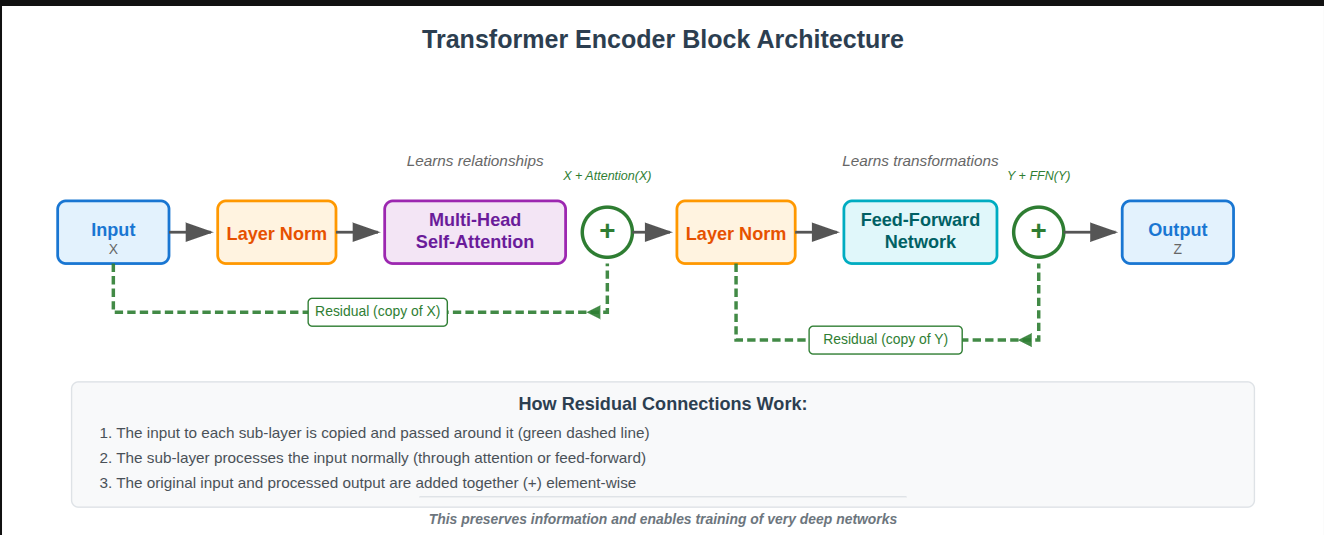

 ## Single Encoder layer


In [4]:
# Create a simple encoder block with small dimensions for demonstration
encoder_demo = EncoderBlock(d_model=4, nhead=1, ffn_mult=4)

# Create a sample input: (batch_size=2, sequence_length=3, d_model=4)
sample_input = torch.randn(2, 3, 4)

print("Input shape:", sample_input.shape)
print("Input tensor:\n", sample_input)

# Pass through encoder block
output = encoder_demo(sample_input)

print("\nOutput shape:", output.shape)
print("Output tensor:\n", output)

# Notice that the shape remains the same
print("\nShape preserved: Input shape == Output shape:", sample_input.shape == output.shape)

Input shape: torch.Size([2, 3, 4])
Input tensor:
 tensor([[[ 1.3032,  0.4879,  1.1340, -0.3556],
         [ 0.3618,  1.9993,  0.6630,  0.7047],
         [-0.9291,  0.2762, -0.5389,  0.4626]],

        [[-0.8719, -0.0271, -0.3532,  1.4639],
         [ 1.2554, -0.7150,  0.8539,  0.5130],
         [ 0.5397,  0.5655,  0.5058,  0.2225]]])

Output shape: torch.Size([2, 3, 4])
Output tensor:
 tensor([[[ 1.0026,  0.2121,  1.4273,  0.1655],
         [ 0.4462,  1.7480,  0.8359,  1.2673],
         [-0.9382, -0.1464, -0.3801,  0.8587]],

        [[-0.8144, -0.2512, -0.4787,  1.6496],
         [ 0.5040, -1.2128,  0.8961,  0.6108],
         [ 0.3139,  0.4903,  0.5755,  0.6699]]], grad_fn=<AddBackward0>)

Shape preserved: Input shape == Output shape: True


# Positional Encoding

Positional encoding is used to provide the Transformer with information about the order of tokens in a sequence. Since the Transformer processes all tokens in parallel, it has no inherent notion of position. Positional encodings solve this by adding a unique vector to the embedding of each token.

The original Transformer paper uses **sine** and **cosine** functions to generate these vectors.

For a model with embedding dimension `d_model`, the positional encoding for a token at position `pos` is defined as:

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

where:

- `pos` = position of the token in the sequence (0, 1, 2, ...)
- `i` = embedding dimension pair index
- `d_model` = embedding dimension

---

## Example

```python
sentence = "hello world"
embedding_dim = 6
```

Each token receives a positional encoding vector of length `embedding_dim`.

### Position = 0

```text
[
    sin(0 / 10000^(0/6)),
    cos(0 / 10000^(0/6)),
    sin(0 / 10000^(2/6)),
    cos(0 / 10000^(2/6)),
    sin(0 / 10000^(4/6)),
    cos(0 / 10000^(4/6))
]
```

Since:

- `sin(0) = 0`
- `cos(0) = 1`

The positional encoding becomes:

```text
[0, 1, 0, 1, 0, 1]
```

### Position = 1

```text
[
    sin(1 / 10000^(0/6)),
    cos(1 / 10000^(0/6)),
    sin(1 / 10000^(2/6)),
    cos(1 / 10000^(2/6)),
    sin(1 / 10000^(4/6)),
    cos(1 / 10000^(4/6))
]
```

Similarly, positional encodings are generated for every position from **0** to **N − 1**, where **N** is the total number of tokens.

---

## General Formula

For an embedding dimension `d_model`, the positional encoding vector at position `pos` is:

```text
[
    sin(pos / 10000^(0/d_model)),
    cos(pos / 10000^(0/d_model)),
    sin(pos / 10000^(2/d_model)),
    cos(pos / 10000^(2/d_model)),
    ...
    sin(pos / 10000^((d_model-2)/d_model)),
    cos(pos / 10000^((d_model-2)/d_model))
]
```

---

## Key Points

- Each position receives a unique vector.
- Even dimensions (0, 2, 4, ...) use the **sine** function.
- Odd dimensions (1, 3, 5, ...) use the **cosine** function.
- Different frequencies allow the model to capture both short- and long-range positional relationships.
- The positional encoding vector is **added** to the token embedding before being passed to the Transformer.

The final input to the Transformer is:

$$
\text{Input Embedding} = \text{Token Embedding} + \text{Positional Encoding}
$$

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):

        super().__init__()
        self.max_len = max_len
        self.d_model = d_model

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(torch.arange(0, d_model, 2).float()*-(torch.log(torch.tensor(10000.0))/d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))
    
    def forward(self, x):

        seq_len = x.size(1)

        return self.pe[:,:seq_len, :]

Input embeddings shape: torch.Size([2, 10, 128])
Input embeddings mean: 0.0051

Output shape (unchanged): torch.Size([1, 10, 128])
Output mean (slightly different): 0.4782


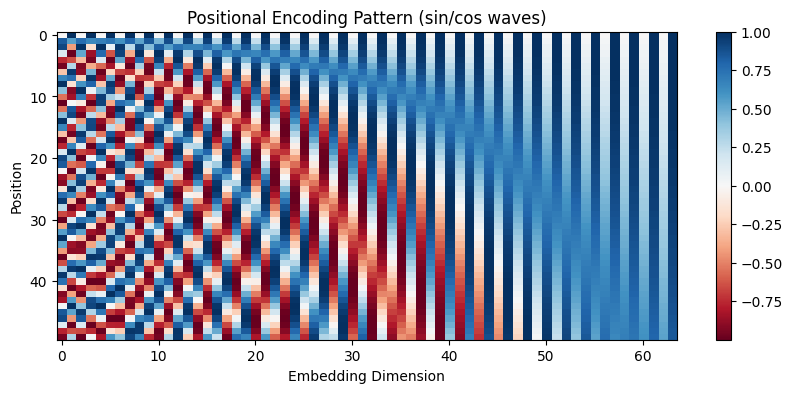

In [6]:
# Example: Create positional encoding and visualize
d_model = 128
max_len = 100
pos_encoder = PositionalEncoding(max_len=max_len, d_model=d_model)

# Create dummy embeddings for a batch of sequences
batch_size = 2
seq_len = 10
dummy_embeddings = torch.randn(batch_size, seq_len, d_model)

print(f"Input embeddings shape: {dummy_embeddings.shape}")
print(f"Input embeddings mean: {dummy_embeddings.mean():.4f}")

# Apply positional encoding
output = pos_encoder(dummy_embeddings)
print(f"\nOutput shape (unchanged): {output.shape}")
print(f"Output mean (slightly different): {output.mean():.4f}")

# Visualize the positional encoding pattern for first half of positions and dimensions
pe_matrix = pos_encoder.pe[0, :50, :64].numpy()
plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Positional Encoding Pattern (sin/cos waves)')
plt.show()

### Understanding the Positional Encoding Visualization

In [8]:
def create_padding_mask(seq, pad_idx =0):

    return (seq==pad_idx)

In [9]:
# Example usage
# Sample batch with padding
batch = torch.tensor([
    [2, 15, 89, 234, 3, 0, 0, 0],   # 5 real tokens, 3 padding
    [2, 45, 67, 89, 123, 234, 3, 0], # 7 real tokens, 1 padding
    [2, 56, 3, 0, 0, 0, 0, 0],       # 3 real tokens, 5 padding
])

# Create padding mask
padding_mask = create_padding_mask(batch, pad_idx=0)
print("Input batch shape:", batch.shape)
print("\nPadding mask:")
print(padding_mask)
print("\nTrue = padding position, False = real token")

Input batch shape: torch.Size([3, 8])

Padding mask:
tensor([[False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False,  True],
        [False, False, False,  True,  True,  True,  True,  True]])

True = padding position, False = real token


### DataLoading

In [13]:
helper_utils.extract_imdb_data()

'Data directory already exists.'

In [14]:
# Load the dataset with default settings (2000 train, 500 test samples)
train_reviews, train_labels, test_reviews, test_labels = helper_utils.get_imdb_data(
    max_train_samples=2000, 
    max_test_samples=500
)


Processing Training Data...


Processing Test Data...



Successfully loaded 2000 training and 500 test samples.


In [18]:
helper_utils.print_data_statistics(train_reviews, train_labels, test_reviews, test_labels)


=== Dataset Statistics ===
Training set:
  Total reviews: 2000
  Positive reviews: 1000
  Negative reviews: 1000

Test set:
  Total reviews: 500
  Positive reviews: 250
  Negative reviews: 250

=== Sample Reviews ===

--- Positive Review Example ---
Label: Positive
Text (first 400 chars): I've seen this movie and I must say I'm very impressed. There are not much movies I like, but I do like this one. You should see this movie by yourself and comment it,because this is one of my most favorite movie. I fancy to see this again. Action fused with a fantastic story. Very impressing. I like Modesty's character. Actually she's very mystic and mysterious (I DO like that^^). The bad boy is ...

--- Negative Review Example ---
Label: Negative
Text (first 400 chars): I usually comment only on movies that I like, figuring "everyone to his/her own taste," but here I want to make an exception. The premise of this movie, which somehow seems to get lost in the shuffle, is that these two self-centered

### Text Processing and Data Creation



In [21]:
class IMDBTokenizer:

    def __init__(self, vocab_size =10000):

        self.vocab_size = vocab_size
        self.word_to_idx = {'<pad>':0, '<unk>':1,'<sos>':2,'<eos>':3}

        self.idx_to_word = {0:'<pad>',1:'<unk>',2:'<sos>',3:'<eos>'}

        self.word_freq = Counter()
    
    def tokenize(self, text):

        # lower casing the text
        text = text.lower()

        # eliminating html elements
        text = re.sub(r'<.*?>','', text)

        # filter the string to retain only alphabetic character and whitespace
        text = re.sub(r'[^a-z\s]', '', text)

        # Split into list of word token 
        words = text.split()

        return words


    def build_vocab(self, texts, min_freq = 2):

        print("Building Vocabulary.....")

        for text in texts:
            words = self.tokenize(text)

            self.word_freq.update(words)
        
        ## top (vocab size-4) tokens and 4 tokens are '<pad>','<unk>','<sos>','<eos>'
        most_common = self.word_freq.most_common(self.vocab_size -4)

        idx = 4
        for word, freq in most_common:

            if freq>=min_freq:
                self.word_to_idx[word] = idx
                self.idx_to_word[idx] = word
                idx+=1
        
        print(f"Vocabulary size: {len(self.word_to_idx)}")

    
    def encode(self, text, max_len = 256):

        # tokenize the text and ensuring not more than max_len '<eos>' and '<sos>'
        words = self.tokenize(text)[:max_len-2]

        # initizalize the sequence with 
        indices = [2] ## '<sos>'

        for word in words:

            if word in self.word_to_idx:
                indices.append(self.word_to_idx[word])
            else:
                indices.append(1) # '<unk>'
        
        indices.append(3) # '<eos>'

        ## Padding the sequence with '<pad>' token if the length is less than max_len
        while len(indices) < max_len:
            indices.append(0) # '<pad>'
        
        ## ensuring having exactly max_len tokens in the sequence 
        return indices[:max_len]




In [22]:
# Create tokenizer
tokenizer = IMDBTokenizer(vocab_size=5000)

# Build vocabulary from training reviews
tokenizer.build_vocab(train_reviews, min_freq=2)

# Test tokenizer with a sample sentence
sample_text = "This movie was absolutely fantastic! I loved every minute of it."
print("Original text:", sample_text)

# Tokenize the text
tokens = tokenizer.tokenize(sample_text)
print("\nTokenized:", tokens)

# Encode to indices
encoded = tokenizer.encode(sample_text, max_len=20)
print("\nEncoded (max_len=20):", encoded)

# Decode back to words to verify
decoded_words = [tokenizer.idx_to_word.get(idx, '<unk>') for idx in encoded]
print("\nDecoded words:", decoded_words)

# Show some vocabulary statistics
print(f"\nVocabulary Statistics:")
print(f"Total unique words in vocab: {len(tokenizer.word_to_idx)}")
print(f"Most common words: {tokenizer.word_freq.most_common(10)}")

Building Vocabulary.....
Vocabulary size: 5000
Original text: This movie was absolutely fantastic! I loved every minute of it.

Tokenized: ['this', 'movie', 'was', 'absolutely', 'fantastic', 'i', 'loved', 'every', 'minute', 'of', 'it']

Encoded (max_len=20): [2, 12, 17, 15, 370, 728, 13, 495, 171, 847, 7, 11, 3, 0, 0, 0, 0, 0, 0, 0]

Decoded words: ['<sos>', 'this', 'movie', 'was', 'absolutely', 'fantastic', 'i', 'loved', 'every', 'minute', 'of', 'it', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Vocabulary Statistics:
Total unique words in vocab: 5000
Most common words: [('the', 25381), ('and', 12576), ('a', 12490), ('of', 11158), ('to', 10542), ('is', 8328), ('in', 7266), ('it', 6011), ('this', 5885), ('i', 5884)]


### IMBD DatasetClass


In [23]:
class IMDBDataset(Dataset):

    def __init__(self, reviews, labels, tokenizer, max_len = 256):
        self.tokenizer = tokenizer
        self.max_len = max_len 
        self.data = []
        self.labels = []

        print(f"Processing {len(reviews)} reviews...")
        for review, label in zip(reviews, labels):
            encoded = tokenizer.encode(review, max_len=self.max_len)

            self.data.append(encoded)
            
            self.labels.append(label)
        
        self.data = torch.LongTensor(self.data)

        self.labels = torch.LongTensor(self.labels)

        print(f"Dataset created with shape: {self.data.shape}")

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


### Creating Train and Test Datasets

In [24]:
# Create datasets
max_seq_length = 256  # Maximum sequence length

print("Creating training dataset...")
train_dataset = IMDBDataset(train_reviews, train_labels, tokenizer, max_len=max_seq_length)

print("\nCreating test dataset...")
test_dataset = IMDBDataset(test_reviews, test_labels, tokenizer, max_len=max_seq_length)

# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaders created:")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Examine a single batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"First sequence in batch (first 20 tokens): {sample_batch[0, :20].tolist()}")
print(f"Label for first sequence: {sample_labels[0].item()}")

Creating training dataset...
Processing 2000 reviews...
Dataset created with shape: torch.Size([2000, 256])

Creating test dataset...
Processing 500 reviews...
Dataset created with shape: torch.Size([500, 256])

Data loaders created:
  Training batches: 63
  Test batches: 16

Sample batch shape: torch.Size([32, 256])
Sample labels shape: torch.Size([32])
First sequence in batch (first 20 tokens): [2, 611, 10, 4, 507, 9, 30, 75, 17, 5, 2833, 19, 1, 1, 18, 232, 17, 7, 4, 296]
Label for first sequence: 0


### Building the Sentiment Classification Model with Custom Encode


In [ ]:

class EncoderBlock(nn.Module):

    def __init__(self, d_model = 4, nhead = 1, ffn_mult = 4):

        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(d_model, nhead, batch_first = True)

        self.ln2 = nn.LayerNorm(d_model)

        hidden = ffn_mult * d_model

        self.ffn = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.ReLU(),
            nn.Linear(hidden,d_model)

        )

    def forward(self, x):

        x_norm = self.ln1(x)

        attn_out, _ = self.mha(x_norm, x_norm, x_norm)    

        x = x + attn_out 

        ffn_in  = self.ln2(x)

        ffn_out = self.ffn(ffn_in)

        x = x+ ffn_out

        return x



In [25]:
class IMDBSentimentModelWithCustomEncoder(nn.Module):

    def __init__(self, vocab_size, d_model = 128, num_layers = 2, max_len =512, dropout =0.1):
        
        super().__init__()

        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)

        self.positional_encoding= PositionalEncoding(max_len, d_model)

        self.dropout   = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList([
            EncoderBlock(d_model = d_model, nhead =8, ffn_mult = 4)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(d_model, 2)

    
    def forward(self, x):

        x =self.embedding(x)*math.sqrt(self.d_model)

        pos_encoding = self.positional_encoding(x)

        x = x + pos_encoding

        x = self.dropout(x)

        for encoder_layer in self.encoder_layers:
            x= encoder_layer(x)

        x = x.mean(dim = 1)

        output = self.classifier(x)

        return output


        

In [26]:
# Get vocabulary size
vocab_size = len(tokenizer.word_to_idx)

# Create the model
model = IMDBSentimentModelWithCustomEncoder(
    vocab_size=vocab_size,
    d_model=128,
    num_layers = 2
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created: IMDBSentimentModel")
print(f"Total learnable parameters: {total_params:,}")

Model created: IMDBSentimentModel
Total learnable parameters: 1,036,802


In [27]:
import torch

# Use all CPU cores
torch.set_num_threads(16)  # or torch.get_num_threads()

In [28]:
# Create a simple input: batch of 2 sequences, each with 5 tokens
tiny_input = torch.tensor([
    [2, 45, 23, 67, 3],  # First review: <sos>, word45, word23, word67, <eos>
    [2, 12, 89, 34, 3]   # Second review: <sos>, word12, word89, word34, <eos>
])
print("=== Step-by-step Forward Pass ===\n")
print("Input (token indices):")
print(tiny_input)
print("Shape:", tiny_input.shape, "\n")

# Step through the model manually
with torch.no_grad():
    # Step 1: Embedding
    embedded = model.embedding(tiny_input)
    print("Step 1 - After embedding:")
    print("  Shape:", embedded.shape)
    print("  Each token is now a vector of size", embedded.shape[-1])
    
    # Step 2: Pass through encoder layers
    x = embedded
    print(f"\nStep 2 - Passing through {len(model.encoder_layers)} encoder layer(s):")
    for i, encoder_layer in enumerate(model.encoder_layers):
        x = encoder_layer(x)
        print(f"  After encoder layer {i+1}:")
        print(f"    Shape: {x.shape}")
        if i == 0:
            print("    Note: shape is unchanged, but representations are refined")
    
    encoded = x
    print(f"\nAfter all encoder layers:")
    print(f"  Final encoded shape: {encoded.shape}")
    print("  Each token now has a contextualized representation")
    
    # Step 3: Pooling
    pooled = encoded.mean(dim=1)
    print("\nStep 3 - After averaging across sequence:")
    print("  Shape:", pooled.shape)
    print("  Now we have one vector per review")
    
    # Step 4: Classification
    output = model.classifier(pooled)
    print("\nStep 4 - Final classification scores:")
    print("  Shape:", output.shape)
    print("  Raw scores (logits):", output)
    
    # Convert to probabilities
    probs = torch.softmax(output, dim=1)
    print("\n  Probabilities [negative, positive]:")
    for i, p in enumerate(probs):
        print(f"    Review {i}: [{p[0]:.3f}, {p[1]:.3f}]")

=== Step-by-step Forward Pass ===

Input (token indices):
tensor([[ 2, 45, 23, 67,  3],
        [ 2, 12, 89, 34,  3]])
Shape: torch.Size([2, 5]) 

Step 1 - After embedding:
  Shape: torch.Size([2, 5, 128])
  Each token is now a vector of size 128

Step 2 - Passing through 2 encoder layer(s):
  After encoder layer 1:
    Shape: torch.Size([2, 5, 128])
    Note: shape is unchanged, but representations are refined
  After encoder layer 2:
    Shape: torch.Size([2, 5, 128])

After all encoder layers:
  Final encoded shape: torch.Size([2, 5, 128])
  Each token now has a contextualized representation

Step 3 - After averaging across sequence:
  Shape: torch.Size([2, 128])
  Now we have one vector per review

Step 4 - Final classification scores:
  Shape: torch.Size([2, 2])
  Raw scores (logits): tensor([[-0.1335, -0.5152],
        [ 0.2544, -0.4413]])

  Probabilities [negative, positive]:
    Review 0: [0.594, 0.406]
    Review 1: [0.667, 0.333]


In [29]:
## infernece on single bathch
# Get a batch from our data loader
sample_input, sample_labels = next(iter(train_loader))

print("Testing with real data:")
print(f"Batch shape: {sample_input.shape}")

# Forward pass
with torch.no_grad():
    output = model(sample_input)

# Get predictions
predictions = torch.argmax(output, dim=1)
accuracy = (predictions == sample_labels).float().mean()

print(f"\nResults on this batch (untrained model):")
print(f"  Accuracy: {accuracy:.1%}")
print(f"\nFirst 5 predictions vs actual:")
print("="*70)

for i in range(5):
    pred_label = "Positive" if predictions[i] == 1 else "Negative"
    true_label = "Positive" if sample_labels[i] == 1 else "Negative"
    correct = "✓" if predictions[i] == sample_labels[i] else "✗"
    
    # Decode the tokens back to words (first 30 tokens for brevity)
    tokens = sample_input[i][:30].tolist()
    # Remove padding tokens (0s) from the end
    tokens = [t for t in tokens if t != 0]
    # Convert token IDs back to words
    words = [tokenizer.idx_to_word.get(token_id, '<unk>') for token_id in tokens]
    # Join into sentence
    sentence_preview = ' '.join(words[:15]) + '...'  # Show first 15 words
    
    print(f"\nSample {i}:")
    print(f"  Text: {sentence_preview}")
    print(f"  Predicted: {pred_label}, Actual: {true_label} {correct}")

Testing with real data:
Batch shape: torch.Size([32, 256])

Results on this batch (untrained model):
  Accuracy: 43.8%

First 5 predictions vs actual:

Sample 0:
  Text: <sos> this movie is yet another in the long line of no budget no effort...
  Predicted: Negative, Actual: Negative ✓

Sample 1:
  Text: <sos> though <unk> and cage are the <unk> points of this story <unk> and <unk>...
  Predicted: Negative, Actual: Positive ✗

Sample 2:
  Text: <sos> i think this movie would be more enjoyable if everyone thought of it as...
  Predicted: Negative, Actual: Positive ✗

Sample 3:
  Text: <sos> the s were not very kind to <unk> major star charles <unk> starting with...
  Predicted: Negative, Actual: Negative ✓

Sample 4:
  Text: <sos> the first time i watched cold case was after it had run for about...
  Predicted: Negative, Actual: Negative ✓


In [30]:
helper_utils.print_summary(model, vocab_size=vocab_size)


Device available: cpu

Model moved to cpu
Ready for training!

MODEL SUMMARY
Model: IMDBSentimentModelWithCustomEncoder
Vocabulary size: 5000
Embedding dimension: 128
Number of attention heads: 8
Total parameters: 1,036,802

The model is now ready to be trained!


### Training The Model


In [31]:
### loss function 
criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr =learning_rate)

print("Training Setup:")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training Setup:
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Batch size: 32
Training samples: 2000
Test samples: 500


In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Evaluate untrained model
model.eval()
correct = 0
total = 0

print("Evaluating untrained model...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

initial_accuracy = 100 * correct / total
print(f"Initial Test Accuracy (before training): {initial_accuracy:.2f}%")

Evaluating untrained model...
Initial Test Accuracy (before training): 49.20%


In [33]:
# Train the model
history = helper_utils.train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=5,
    device=device  # Optional, will auto-detect if not provided
)

Training on cpu


Epoch 1/5 [Test]: 100%|██████████| 16/16 [00:03<00:00,  4.69it/s, acc=61.2%]


  🎯 New best model! Test Acc: 61.20%
Epoch 1/5 Summary:
  Train - Loss: 0.7555, Acc: 51.95%
  Test   - Loss: 0.6568, Acc: 61.20%
--------------------------------------------------


Epoch 2/5 [Test]: 100%|██████████| 16/16 [00:04<00:00,  3.90it/s, acc=65.2%]


  🎯 New best model! Test Acc: 65.20%
Epoch 2/5 Summary:
  Train - Loss: 0.6347, Acc: 64.25%
  Test   - Loss: 0.6450, Acc: 65.20%
--------------------------------------------------


...

  🎯 New best model! Test Acc: 73.60%
Epoch 3/5 Summary:
  Train - Loss: 0.5137, Acc: 74.10%
  Test   - Loss: 0.5333, Acc: 73.60%
--------------------------------------------------


Epoch 4/5 [Test]: 100%|██████████| 16/16 [00:04<00:00,  3.77it/s, acc=72.8%]


Epoch 4/5 Summary:
  Train - Loss: 0.4385, Acc: 79.65%
  Test   - Loss: 0.5530, Acc: 72.80%
--------------------------------------------------


Epoch 5/5 [Test]: 100%|██████████| 16/16 [00:03<00:00,  4.19it/s, acc=76.6%]

  🎯 New best model! Test Acc: 76.60%
Epoch 5/5 Summary:
  Train - Loss: 0.3481, Acc: 84.65%
  Test   - Loss: 0.5358, Acc: 76.60%
--------------------------------------------------

Training completed! Best model restored from epoch 5
Best Test Accuracy: 76.60%


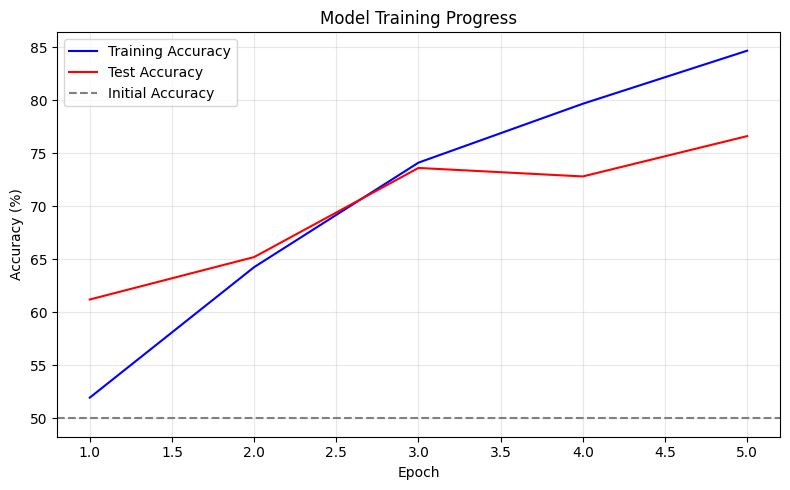

Accuracy Summary:
  Started at: 50.00% (untrained)
  Final test accuracy: 76.60%
  Total improvement: +26.60%


In [34]:
helper_utils.plot_training_history(history)

In [35]:
torch.save(model.state_dict(),"trained_imdb_sentiment_model.pth")

### Using Pytorch Built in Transformer Encoder Layer